# Rollout Cases for `HexnerMod3DGame` (Amortized Alpha)

This notebook:
- loads a trained 3-D amortized checkpoint from `train_hexner_mod_3d_amortized.py`
- rebuilds the 3-D Hexner-mod landing game
- evaluates a fixed set of `(prior, x0)` cases
- generates deterministic rollout trajectories per true type
- compares incomplete-information behavior against a complete-information baseline
- plots 3-D trajectories, belief traces, and landing diagnostics

It is designed for the 3-D mod game with:
- strong shared `z` landing penalty
- terminal zero-velocity penalty
- amortized `alpha(x0, p0)` prediction across multiple initial states


In [8]:
import os
import sys
from typing import Dict, List, Optional

import numpy as np
try:
    import pandas as pd
except ImportError:
    pd = None
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Add repo root to path (works from notebooks/ or repo root)
CWD = os.getcwd()
if os.path.basename(CWD) == "notebooks":
    REPO_ROOT = os.path.abspath(os.path.join(CWD, ".."))
else:
    REPO_ROOT = CWD
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

print("Repo root:", REPO_ROOT)


Repo root: /Users/mghimire/Research/MPC_2p0s1


In [15]:
from MPC_2p0s1.config.base_config import GameConfig, project_relative
from MPC_2p0s1.core.action_spaces import BoxActionSpace
from MPC_2p0s1.games.hexner_mod_3d_game_original import HexnerMod3DOriginalGame, HexnerMod3DOriginalParams
from MPC_2p0s1.outer_opt.amortized_alpha import (
    AmortizedAlphaConfig,
    AmortizedAlphaParam,
    primal_objective_from_alpha,
)
from MPC_2p0s1.tree.indexing import FullIaryTreeIndexer
from MPC_2p0s1.tree.rollout import rollout_trajectory


In [16]:
device = torch.device("cpu")
CHECKPOINT_PATH = project_relative("runs/hexner_mod_3d_amortized_vel_low_running_cost/latest.pt")
USE_ACTION_CLIP = False
PROJECT_ALPHA_ONEHOT = False

print(f"Checkpoint: {CHECKPOINT_PATH}")


def _rebuild_game_config(meta_dict: Dict) -> GameConfig:
    cfg = GameConfig()
    for k, v in meta_dict.items():
        setattr(cfg, k, v)

    if not hasattr(cfg, "dx"):
        cfg.dx = cfg.dx1 + cfg.dx2
    if not hasattr(cfg, "tau") and hasattr(cfg, "T") and hasattr(cfg, "K"):
        cfg.tau = cfg.T / cfg.K

    cfg.device = str(device)
    cfg.device_resolved = device
    if not hasattr(cfg, "dtype"):
        cfg.dtype = torch.float32

    return cfg


def _parse_tuple_floats(csv_text: str):
    return tuple(float(v.strip()) for v in str(csv_text).split(",") if v.strip())


def _parse_tuple_ints(csv_text: str):
    return tuple(int(v.strip()) for v in str(csv_text).split(",") if v.strip())


def _maybe_parse_tuple_floats(value):
    if value is None:
        return None
    if isinstance(value, (tuple, list)):
        return tuple(float(v) for v in value)
    text = str(value).strip()
    if text.lower() == "none" or text == "":
        return None
    return _parse_tuple_floats(text)


def _parse_type_k_diags(value, I: int, dx1: int):
    if value is None:
        return None
    if isinstance(value, (tuple, list)):
        out = []
        for row in value:
            row_vals = tuple(float(v) for v in row)
            if len(row_vals) != dx1:
                raise ValueError(f"Expected dx1={dx1} values per type_k_diags row, got {len(row_vals)}")
            out.append(row_vals)
        if len(out) != I:
            raise ValueError(f"Expected I={I} rows in type_k_diags, got {len(out)}")
        return tuple(out)

    rows = [r.strip() for r in str(value).split(";") if r.strip()]
    if len(rows) != I:
        raise ValueError(f"Expected I={I} rows in type_k_diags, got {len(rows)}")
    parsed = []
    for row in rows:
        vals = tuple(float(v.strip()) for v in row.split(",") if v.strip())
        if len(vals) != dx1:
            raise ValueError(f"Expected dx1={dx1} values per type_k_diags row, got {len(vals)}")
        parsed.append(vals)
    return tuple(parsed)


Checkpoint: /Users/mghimire/Research/MPC_2p0s1/runs/hexner_mod_3d_amortized_vel_low_running_cost/latest.pt


In [31]:
payload = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
meta = payload.get("meta", {})

if "model_state_dict" not in payload:
    raise RuntimeError(
        "Checkpoint does not contain 'model_state_dict'. "
        "Please use an amortized checkpoint from train_hexner_mod_3d_amortized.py."
    )

game_cfg = _rebuild_game_config(meta.get("game_config", {}))
args_ckpt = meta.get("args", {})

indexer = FullIaryTreeIndexer(I=game_cfg.I, K=game_cfg.K)

hidden_dims = _parse_tuple_ints(args_ckpt.get("hidden_dims", "256,256"))
amort_cfg = AmortizedAlphaConfig(
    hidden_dims=hidden_dims,
    activation=str(args_ckpt.get("activation", "silu")),
    dropout=float(args_ckpt.get("dropout", 0.0)),
)

model = AmortizedAlphaParam(
    indexer=indexer,
    dx=game_cfg.dx,
    I=game_cfg.I,
    cfg=amort_cfg,
    dtype=game_cfg.dtype,
    device=device,
)
model.load_state_dict(payload["model_state_dict"])
model.eval()

hexner_mod_params = HexnerMod3DOriginalParams(
    theta_values=_parse_tuple_floats(args_ckpt.get("theta_values", "-1.0,1.0")),
    target_z=_maybe_parse_tuple_floats(args_ckpt.get("target_z", None)),
    R1_scale=float(args_ckpt.get("R1_scale", 1.0)),
    R2_scale=float(args_ckpt.get("R2_scale", 0.4)),
    K1_scale=float(args_ckpt.get("K1_scale", 1.0)),
    K2_scale=float(args_ckpt.get("K2_scale", 1.0)),
    extra_position_scale=float(args_ckpt.get("extra_position_scale", 1.0)),
    terminal_velocity_scale=float(args_ckpt.get("terminal_velocity_scale", 1.0)),
    type_k_diags=_parse_type_k_diags(args_ckpt.get("type_k_diags", None), I=game_cfg.I, dx1=game_cfg.dx1),
)

game = HexnerMod3DOriginalGame(cfg=game_cfg, params=hexner_mod_params, prior=None)
action_space = BoxActionSpace.from_config(game_cfg)
eval_action_space = action_space if USE_ACTION_CLIP else None

print(
    f"Loaded amortized checkpoint: step={meta.get('step', '?')}, "
    f"train_loss={meta.get('train_loss', '?')}, eval_loss={meta.get('eval_loss', '?')}"
)
print(f"Game: I={game_cfg.I}, K={game_cfg.K}, T={game_cfg.T}, dtype={game_cfg.dtype}")
print(f"Model hidden_dims={hidden_dims}, activation={amort_cfg.activation}, dropout={amort_cfg.dropout}")
print(f"Eval action clipping enabled: {USE_ACTION_CLIP}")
print(f"Project alpha to one-hot: {PROJECT_ALPHA_ONEHOT}")
print(f"Targets type0={game.type_targets()[0].detach().cpu().tolist()}")
print(f"Targets type1={game.type_targets()[1].detach().cpu().tolist()}")
print(f"K1 diag type0={torch.diag(game._K1_type[0]).detach().cpu().tolist()}")
print(f"K1 diag type1={torch.diag(game._K1_type[1]).detach().cpu().tolist()}")
print(f"R1_scale={args_ckpt["R1_scale"]}")
print(f"R1_scale={args_ckpt["R2_scale"]}")


Loaded amortized checkpoint: step=1999, train_loss=0.15493027865886688, eval_loss=0.1518872082233429
Game: I=2, K=10, T=1.0, dtype=torch.float32
Model hidden_dims=(64,), activation=silu, dropout=0.0
Eval action clipping enabled: False
Project alpha to one-hot: False
Targets type0=[-1.0, -1.0, -0.0, -0.0, -0.0, -0.0]
Targets type1=[1.0, 1.0, 0.0, 0.0, 0.0, 0.0]
K1 diag type0=[1.0, 20.0, 20.0, 20.0, 20.0, 20.0]
K1 diag type1=[20.0, 1.0, 20.0, 20.0, 20.0, 20.0]
R1_scale=0.25
R1_scale=0.1


In [21]:
dtype = game_cfg.dtype
base_x0 = game.default_initial_state().to(device=device, dtype=dtype)


def make_x0(
    p1x=-1.0, p1y=0.0, p1z=1.0, p1vx=0.0, p1vy=0.0, p1vz=0.0,
    p2x=1.0, p2y=0.0, p2z=1.0, p2vx=0.0, p2vy=0.0, p2vz=0.0,
):
    return torch.tensor(
        [p1x, p1y, p1z, p1vx, p1vy, p1vz, p2x, p2y, p2z, p2vx, p2vy, p2vz],
        device=device,
        dtype=dtype,
    )


x0_center = base_x0.clone()
# x0_offset = make_x0(p1x=-1.20, p1y=-0.20, p1z=1.25, p2x=1.10, p2y=0.35, p2z=0.90)
# x0_flip = make_x0(p1x=-0.85, p1y=0.30, p1z=0.95, p2x=0.90, p2y=-0.30, p2z=1.20)

x0_offset = make_x0(1.2, -1.9, 1.7,  0.0, 0.0, 0.0, -1.6,  2.0, 0.3,  0.0, 0.0, 0.0)   # P2: px, py, pz, vx, vy, vz)
x0_flip = make_x0(p1x=-0.85, p1y=0.30, p1z=0.95, p2x=0.90, p2y=-0.30, p2z=1.20)

scenarios: List[Dict] = [
    {
        "name": "S0 balanced_center",
        "prior": torch.tensor([0.5, 0.5], device=device, dtype=dtype),
        "x0": x0_center,
        "note": "default landing geometry",
    },
    {
        "name": "S1 balanced_offset",
        "prior": torch.tensor([0.5, 0.5], device=device, dtype=dtype),
        "x0": x0_offset,
        "note": "both players displaced in 3-D",
    },
    {
        "name": "S2 type1_likely_offset",
        "prior": torch.tensor([0.2, 0.8], device=device, dtype=dtype),
        "x0": x0_flip,
        "note": "offset state with prior favoring type +1",
    },
]

print("Scenarios:")
for s in scenarios:
    print(f"  {s['name']}: prior={s['prior'].tolist()}, note={s['note']}")


Scenarios:
  S0 balanced_center: prior=[0.5, 0.5], note=default landing geometry
  S1 balanced_offset: prior=[0.5, 0.5], note=both players displaced in 3-D
  S2 type1_likely_offset: prior=[0.20000000298023224, 0.800000011920929], note=offset state with prior favoring type +1


In [22]:
def rollout_total_cost(game: HexnerMod3DGame, rollout, type_index: int) -> float:
    u = rollout.u_traj
    v = rollout.v_traj
    R_i = game.R[type_index]
    S_i = game.S[type_index]

    tau = float(game.cfg.tau)
    run_u = 0.5 * tau * torch.einsum("kd,dd,kd->k", u, R_i, u)
    run_v = 0.5 * tau * torch.einsum("kd,dd,kd->k", v, S_i, v)
    running = (run_u - run_v).sum()
    terminal = game.terminal_cost_type(type_index, rollout.x_traj[-1])
    return float((running + terminal).detach().cpu().item())


def project_alpha_onehot(alpha: torch.Tensor) -> torch.Tensor:
    idx = torch.argmax(alpha, dim=-1, keepdim=True)
    out = torch.zeros_like(alpha)
    out.scatter_(-1, idx, 1.0)
    return out


def terminal_metrics(rollout) -> Dict[str, float]:
    xT = rollout.x_traj[-1].detach().cpu()
    dx1 = game.cfg.dx1
    p1_pos = xT[:3]
    p1_vel = xT[3:6]
    p2_pos = xT[dx1:dx1+3]
    p2_vel = xT[dx1+3:dx1+6]
    return {
        "p1_xT": float(p1_pos[0].item()),
        "p1_yT": float(p1_pos[1].item()),
        "p1_zT": float(p1_pos[2].item()),
        "p1_speed_T": float(torch.linalg.norm(p1_vel).item()),
        "p2_xT": float(p2_pos[0].item()),
        "p2_yT": float(p2_pos[1].item()),
        "p2_zT": float(p2_pos[2].item()),
        "p2_speed_T": float(torch.linalg.norm(p2_vel).item()),
    }


def evaluate_scenario(prior: torch.Tensor, x0: torch.Tensor):
    with torch.no_grad():
        alpha_tree = model.single_alpha(x0=x0, p0=prior)
        if PROJECT_ALPHA_ONEHOT:
            alpha_tree = project_alpha_onehot(alpha_tree)

    loss, details = primal_objective_from_alpha(
        game=game,
        alpha=alpha_tree,
        indexer=indexer,
        x0=x0,
        p0=prior,
        action_space=eval_action_space,
        return_details=True,
    )

    belief_tree = details["belief_tree"]
    riccati_sol = details["riccati_solution"]

    out = {
        "root_loss": float(loss.detach().cpu().item()),
        "alpha": alpha_tree,
        "belief_tree": belief_tree,
        "riccati_sol": riccati_sol,
        "rollouts": {},
        "complete_info": {},
    }

    for type_idx in range(game.I):
        ro = rollout_trajectory(
            game=game,
            indexer=indexer,
            belief_tree=belief_tree,
            riccati_sol=riccati_sol,
            alpha=alpha_tree,
            x0=x0,
            type_index=type_idx,
            action_space=eval_action_space,
            sample_actions=False,
            generator=None,
        )
        cost_policy = rollout_total_cost(game=game, rollout=ro, type_index=type_idx)

        prior_ci = torch.zeros_like(prior)
        prior_ci[type_idx] = 1.0
        with torch.no_grad():
            alpha_ci = model.single_alpha(x0=x0, p0=prior_ci)
            if PROJECT_ALPHA_ONEHOT:
                alpha_ci = project_alpha_onehot(alpha_ci)

        loss_ci, details_ci = primal_objective_from_alpha(
            game=game,
            alpha=alpha_ci,
            indexer=indexer,
            x0=x0,
            p0=prior_ci,
            action_space=eval_action_space,
            return_details=True,
        )

        ro_ci = rollout_trajectory(
            game=game,
            indexer=indexer,
            belief_tree=details_ci["belief_tree"],
            riccati_sol=details_ci["riccati_solution"],
            alpha=alpha_ci,
            x0=x0,
            type_index=type_idx,
            action_space=eval_action_space,
            sample_actions=False,
            generator=None,
        )
        cost_ci = rollout_total_cost(game=game, rollout=ro_ci, type_index=type_idx)

        out["rollouts"][type_idx] = {
            "rollout": ro,
            "cost": cost_policy,
            "terminal": terminal_metrics(ro),
        }
        out["complete_info"][type_idx] = {
            "prior": prior_ci,
            "rollout": ro_ci,
            "cost": cost_ci,
            "root_loss": float(loss_ci.detach().cpu().item()),
            "terminal": terminal_metrics(ro_ci),
        }

    return out


def _rollout_positions(rollout):
    x = rollout.x_traj.detach().cpu().numpy()
    dx1 = game.cfg.dx1
    pos1 = x[:, :3]
    pos2 = x[:, dx1:dx1+3]
    return pos1, pos2


def set_axes_equal_3d(ax, points: np.ndarray) -> None:
    mins = points.min(axis=0)
    maxs = points.max(axis=0)
    center = 0.5 * (mins + maxs)
    radius = max(float(np.max(maxs - mins)) * 0.5, 1.0)
    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(max(center[2] - radius, -0.2), center[2] + radius)
    if hasattr(ax, "set_box_aspect"):
        ax.set_box_aspect((1.0, 1.0, 0.8))


def plot_landing_context_3d(ax, game: HexnerMod3DGame) -> None:
    targets = game.type_targets().detach().cpu().numpy()[:, :3]
    colors = ["tab:red", "tab:blue"]

    x_lim = (-1.8, 1.8)
    y_lim = (-1.8, 1.8)
    xx, yy = np.meshgrid(np.linspace(*x_lim, 2), np.linspace(*y_lim, 2))
    zz = np.zeros_like(xx)
    ax.plot_surface(xx, yy, zz, alpha=0.08, color="gray", shade=False)

    for i, color in enumerate(colors[: targets.shape[0]]):
        ax.scatter(
            targets[i, 0],
            targets[i, 1],
            targets[i, 2],
            marker="*",
            s=220,
            color=color,
            edgecolors="black",
            label=f"type {i} target",
            zorder=6,
        )

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.view_init(elev=24, azim=-55)


def plot_rollout_3d(ax, rollout, label_prefix: str, line_style: str, alpha: float = 1.0) -> None:
    pos1, pos2 = _rollout_positions(rollout)
    ax.plot(pos1[:, 0], pos1[:, 1], pos1[:, 2], line_style, color="tab:red", linewidth=2.2, alpha=alpha, label=f"{label_prefix} P1")
    ax.plot(pos2[:, 0], pos2[:, 1], pos2[:, 2], line_style, color="tab:blue", linewidth=2.2, alpha=alpha, label=f"{label_prefix} P2")
    ax.scatter(pos1[0, 0], pos1[0, 1], pos1[0, 2], color="tab:red", marker="o", s=40, alpha=alpha)
    ax.scatter(pos2[0, 0], pos2[0, 1], pos2[0, 2], color="tab:blue", marker="o", s=40, alpha=alpha)
    ax.scatter(pos1[-1, 0], pos1[-1, 1], pos1[-1, 2], color="tab:red", marker="^", s=55, alpha=alpha)
    ax.scatter(pos2[-1, 0], pos2[-1, 1], pos2[-1, 2], color="tab:blue", marker="^", s=55, alpha=alpha)


In [23]:
scenario_results = {}
for s in scenarios:
    print(f"Running {s['name']}")
    scenario_results[s["name"]] = evaluate_scenario(prior=s["prior"], x0=s["x0"])

print("Done.")


Running S0 balanced_center
Running S1 balanced_offset
Running S2 type1_likely_offset
Done.


In [24]:
rows = []
agg_rows = []
for s in scenarios:
    name = s["name"]
    res = scenario_results[name]
    p0 = s["prior"].detach().cpu().numpy()

    policy_pw = 0.0
    ci_pw = 0.0
    ci_root_pw = 0.0
    for type_idx in range(game.I):
        policy_entry = res["rollouts"][type_idx]
        ci_entry = res["complete_info"][type_idx]
        policy_term = policy_entry["terminal"]
        ci_term = ci_entry["terminal"]

        rows.append(
            {
                "Scenario": name,
                "Type": type_idx,
                "Prior": [round(float(x), 3) for x in p0.tolist()],
                "Root objective": round(res["root_loss"], 5),
                "Policy cost": round(policy_entry["cost"], 5),
                "CI cost": round(ci_entry["cost"], 5),
                "Policy - CI": round(policy_entry["cost"] - ci_entry["cost"], 5),
                "Policy P1 z_T": round(policy_term["p1_zT"], 5),
                "Policy P1 speed_T": round(policy_term["p1_speed_T"], 5),
                "Policy P2 z_T": round(policy_term["p2_zT"], 5),
                "Policy P2 speed_T": round(policy_term["p2_speed_T"], 5),
                "CI P1 z_T": round(ci_term["p1_zT"], 5),
                "CI P1 speed_T": round(ci_term["p1_speed_T"], 5),
                "CI P2 z_T": round(ci_term["p2_zT"], 5),
                "CI P2 speed_T": round(ci_term["p2_speed_T"], 5),
            }
        )

        policy_pw += float(p0[type_idx]) * float(policy_entry["cost"])
        ci_pw += float(p0[type_idx]) * float(ci_entry["cost"])
        ci_root_pw += float(p0[type_idx]) * float(ci_entry["root_loss"])

    agg_rows.append(
        {
            "Scenario": name,
            "Prior": [round(float(x), 3) for x in p0.tolist()],
            "J_incomplete(root)": round(float(res["root_loss"]), 6),
            "J_complete_info(expected root)": round(ci_root_pw, 6),
            "Root gap": round(float(res["root_loss"]) - ci_root_pw, 6),
            "Prior-weighted policy cost": round(policy_pw, 6),
            "Prior-weighted CI cost": round(ci_pw, 6),
            "Policy - CI (pw)": round(policy_pw - ci_pw, 6),
        }
    )

if pd is not None:
    summary_df = pd.DataFrame(rows)
    agg_df = pd.DataFrame(agg_rows)
    print("Scenario-level prior-weighted comparison:")
    display(agg_df)
    display(summary_df)
else:
    summary_df = rows
    agg_df = agg_rows
    print("Scenario-level prior-weighted comparison:")
    for row in agg_rows:
        print(row)
    print("\nDetailed rows:")
    for row in rows:
        print(row)


Scenario-level prior-weighted comparison:
{'Scenario': 'S0 balanced_center', 'Prior': [0.5, 0.5], 'J_incomplete(root)': 0.151887, 'J_complete_info(expected root)': 0.23445, 'Root gap': -0.082562, 'Prior-weighted policy cost': 0.151637, 'Prior-weighted CI cost': 0.234449, 'Policy - CI (pw)': -0.082813}
{'Scenario': 'S1 balanced_offset', 'Prior': [0.5, 0.5], 'J_incomplete(root)': -0.647121, 'J_complete_info(expected root)': 0.265957, 'Root gap': -0.913077, 'Prior-weighted policy cost': -0.519377, 'Prior-weighted CI cost': 0.265951, 'Policy - CI (pw)': -0.785328}
{'Scenario': 'S2 type1_likely_offset', 'Prior': [0.2, 0.8], 'J_incomplete(root)': 0.222823, 'J_complete_info(expected root)': 0.313667, 'Root gap': -0.090845, 'Prior-weighted policy cost': 0.218892, 'Prior-weighted CI cost': 0.313667, 'Policy - CI (pw)': -0.094774}

Detailed rows:
{'Scenario': 'S0 balanced_center', 'Type': 0, 'Prior': [0.5, 0.5], 'Root objective': 0.15189, 'Policy cost': -0.18359, 'CI cost': -0.18359, 'Policy - C

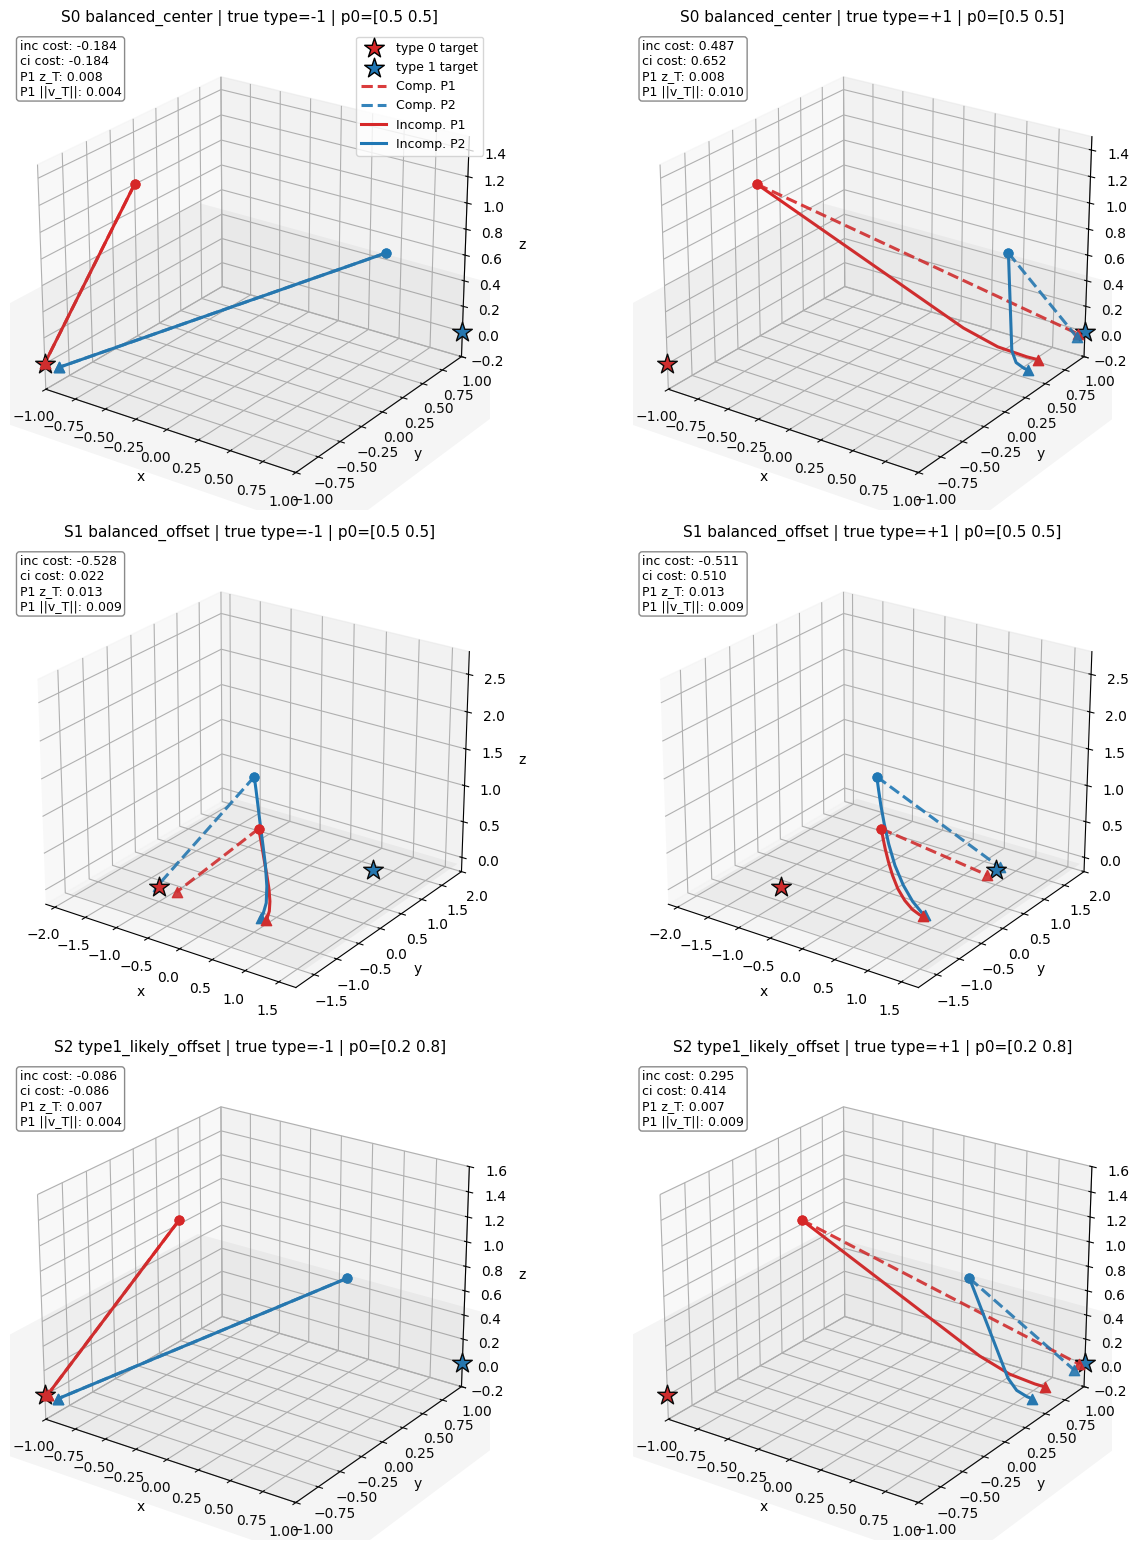

In [28]:
num_rows = len(scenarios)
num_cols = game.I
fig = plt.figure(figsize=(7.0 * num_cols, 5.2 * num_rows))

for r, s in enumerate(scenarios):
    name = s["name"]
    prior_np = s["prior"].detach().cpu().numpy()
    res = scenario_results[name]

    for c in range(num_cols):
        ax = fig.add_subplot(num_rows, num_cols, r * num_cols + c + 1, projection="3d")
        plot_landing_context_3d(ax=ax, game=game)

        ro = res["rollouts"][c]["rollout"]
        ro_ci = res["complete_info"][c]["rollout"]
        plot_rollout_3d(ax=ax, rollout=ro_ci, label_prefix="Comp.", line_style="--", alpha=0.90)
        plot_rollout_3d(ax=ax, rollout=ro, label_prefix="Incomp.", line_style="-", alpha=1.00)

        pos1, pos2 = _rollout_positions(ro)
        pos1_ci, pos2_ci = _rollout_positions(ro_ci)
        pts = np.concatenate([pos1, pos2, pos1_ci, pos2_ci, game.type_targets().detach().cpu().numpy()[:, :3]], axis=0)
        set_axes_equal_3d(ax, pts)

        policy_cost = res["rollouts"][c]["cost"]
        ci_cost = res["complete_info"][c]["cost"]
        term = res["rollouts"][c]["terminal"]
        ax.text2D(
            0.02,
            0.98,
            f"inc cost: {policy_cost:.3f}\n"
            f"ci cost: {ci_cost:.3f}\n"
            f"P1 z_T: {term['p1_zT']:.3f}\n"
            f"P1 ||v_T||: {term['p1_speed_T']:.3f}",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="gray", alpha=0.92),
        )
        ax.set_title(
            f"{name} | true type={float(game.theta_vals[c]):+.0f} | p0={prior_np.round(2)}",
            fontsize=11,
        )
        if r == 0 and c == 0:
            ax.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()
# plt.savefig('3d_cases.png')


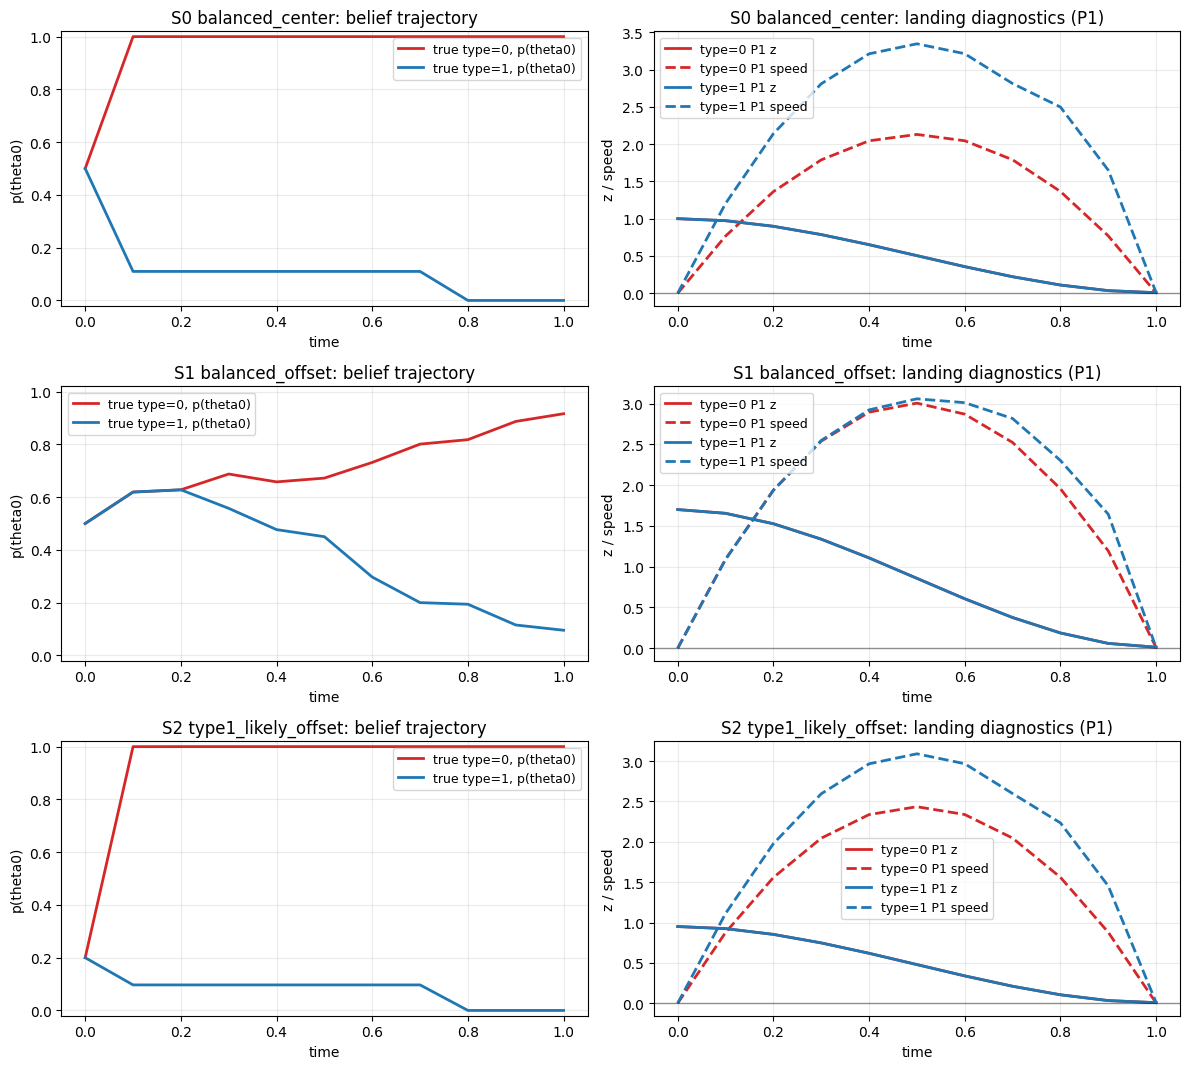

In [26]:
fig, axes = plt.subplots(len(scenarios), 2, figsize=(12, 3.6 * len(scenarios)), squeeze=False)

for r, s in enumerate(scenarios):
    name = s["name"]
    ax_bel = axes[r, 0]
    ax_land = axes[r, 1]

    for type_idx, color in [(0, "tab:red"), (1, "tab:blue")]:
        ro = scenario_results[name]["rollouts"][type_idx]["rollout"]
        b = ro.belief_traj.detach().cpu().numpy()
        x = ro.x_traj.detach().cpu().numpy()
        t = np.linspace(0.0, float(game_cfg.T), x.shape[0])

        ax_bel.plot(t, b[:, 0], color=color, linewidth=2.0, label=f"true type={type_idx}, p(theta0)")

        p1_z = x[:, 2]
        p1_speed = np.linalg.norm(x[:, 3:6], axis=1)
        ax_land.plot(t, p1_z, color=color, linewidth=2.0, label=f"type={type_idx} P1 z")
        ax_land.plot(t, p1_speed, color=color, linewidth=2.0, linestyle="--", label=f"type={type_idx} P1 speed")

    ax_bel.set_title(f"{name}: belief trajectory")
    ax_bel.set_xlabel("time")
    ax_bel.set_ylabel("p(theta0)")
    ax_bel.set_ylim(-0.02, 1.02)
    ax_bel.grid(True, alpha=0.25)
    ax_bel.legend(fontsize=9, loc="best")

    ax_land.axhline(0.0, color="black", linewidth=1.0, alpha=0.4)
    ax_land.set_title(f"{name}: landing diagnostics (P1)")
    ax_land.set_xlabel("time")
    ax_land.set_ylabel("z / speed")
    ax_land.grid(True, alpha=0.25)
    ax_land.legend(fontsize=9, loc="best")

plt.tight_layout()
plt.show()


## Interactive 3D Animation

This section lets you pick one rollout from `scenario_results` and view it as a rotatable 3D Plotly animation. The figure supports click-and-drag rotation, zoom, and play/pause controls.


In [27]:
try:
    import plotly.graph_objects as go
except ImportError:
    go = None

try:
    import ipywidgets as widgets
except ImportError:
    widgets = None


def _animation_result_options():
    options = []
    for s in scenarios:
        name = s["name"]
        for type_idx in range(game.I):
            options.append(
                (
                    f"{name} | true type={type_idx} | incomplete",
                    (name, type_idx, "rollouts"),
                )
            )
            options.append(
                (
                    f"{name} | true type={type_idx} | complete-info",
                    (name, type_idx, "complete_info"),
                )
            )
    return options


def _animation_rollout_arrays(selection):
    scenario_name, type_idx, bucket = selection
    entry = scenario_results[scenario_name][bucket][type_idx]
    rollout = entry["rollout"]
    x = rollout.x_traj.detach().cpu().numpy()
    dx1 = game.cfg.dx1
    pos1 = x[:, :3]
    pos2 = x[:, dx1:dx1+3]
    return pos1, pos2, entry


def _animation_bounds(pos1, pos2):
    targets = game.type_targets().detach().cpu().numpy()[:, :3]
    pts = np.concatenate([pos1, pos2, targets], axis=0)
    mins = pts.min(axis=0)
    maxs = pts.max(axis=0)
    center = 0.5 * (mins + maxs)
    radius = max(float(np.max(maxs - mins)) * 0.55, 1.0)
    return center, radius


def _make_rollout_animation(selection, tail_length: Optional[int] = None):
    scenario_name, type_idx, bucket = selection
    pos1, pos2, entry = _animation_rollout_arrays(selection)
    center, radius = _animation_bounds(pos1, pos2)
    cost = entry["cost"]
    term = entry["terminal"]

    targets = game.type_targets().detach().cpu().numpy()[:, :3]
    x_lim = (center[0] - radius, center[0] + radius)
    y_lim = (center[1] - radius, center[1] + radius)
    xx, yy = np.meshgrid(np.linspace(*x_lim, 2), np.linspace(*y_lim, 2))
    zz = np.zeros_like(xx)

    trace_plane = go.Surface(
        x=xx,
        y=yy,
        z=zz,
        showscale=False,
        opacity=0.12,
        colorscale=[[0.0, 'lightgray'], [1.0, 'lightgray']],
        hoverinfo='skip',
        name='landing plane',
    )

    trace_targets = []
    target_colors = ['red', 'blue']
    for i in range(targets.shape[0]):
        trace_targets.append(
            go.Scatter3d(
                x=[targets[i, 0]],
                y=[targets[i, 1]],
                z=[targets[i, 2]],
                mode='markers',
                marker=dict(size=8, color=target_colors[i % len(target_colors)], symbol='diamond'),
                name=f'type {i} target',
            )
        )

    path1_init = go.Scatter3d(
        x=[pos1[0, 0]], y=[pos1[0, 1]], z=[pos1[0, 2]],
        mode='lines',
        line=dict(color='red', width=7),
        name='P1 path',
    )
    path2_init = go.Scatter3d(
        x=[pos2[0, 0]], y=[pos2[0, 1]], z=[pos2[0, 2]],
        mode='lines',
        line=dict(color='blue', width=7),
        name='P2 path',
    )
    marker1_init = go.Scatter3d(
        x=[pos1[0, 0]], y=[pos1[0, 1]], z=[pos1[0, 2]],
        mode='markers',
        marker=dict(size=6, color='red', symbol='circle'),
        name='P1 current',
    )
    marker2_init = go.Scatter3d(
        x=[pos2[0, 0]], y=[pos2[0, 1]], z=[pos2[0, 2]],
        mode='markers',
        marker=dict(size=6, color='blue', symbol='circle'),
        name='P2 current',
    )

    frames = []
    for k in range(pos1.shape[0]):
        start = 0 if tail_length is None else max(0, k - int(tail_length))
        frames.append(
            go.Frame(
                name=str(k),
                data=[
                    go.Scatter3d(
                        x=pos1[start:k+1, 0], y=pos1[start:k+1, 1], z=pos1[start:k+1, 2],
                        mode='lines', line=dict(color='red', width=7),
                    ),
                    go.Scatter3d(
                        x=pos2[start:k+1, 0], y=pos2[start:k+1, 1], z=pos2[start:k+1, 2],
                        mode='lines', line=dict(color='blue', width=7),
                    ),
                    go.Scatter3d(
                        x=[pos1[k, 0]], y=[pos1[k, 1]], z=[pos1[k, 2]],
                        mode='markers', marker=dict(size=6, color='red', symbol='circle'),
                    ),
                    go.Scatter3d(
                        x=[pos2[k, 0]], y=[pos2[k, 1]], z=[pos2[k, 2]],
                        mode='markers', marker=dict(size=6, color='blue', symbol='circle'),
                    ),
                ],
                traces=[1 + len(trace_targets), 2 + len(trace_targets), 3 + len(trace_targets), 4 + len(trace_targets)],
            )
        )

    title = (
        f"{scenario_name} | true type={type_idx} | {'incomplete' if bucket == 'rollouts' else 'complete-info'}"
        f"<br>cost={cost:.3f}, P1 z_T={term['p1_zT']:.3f}, P1 ||v_T||={term['p1_speed_T']:.3f}"
    )

    fig = go.Figure(
        data=[trace_plane, *trace_targets, path1_init, path2_init, marker1_init, marker2_init],
        frames=frames,
    )
    fig.update_layout(
        title=title,
        width=950,
        height=750,
        scene=dict(
            xaxis_title='x',
            yaxis_title='y',
            zaxis_title='z',
            xaxis=dict(range=[center[0] - radius, center[0] + radius]),
            yaxis=dict(range=[center[1] - radius, center[1] + radius]),
            zaxis=dict(range=[max(center[2] - radius, -0.2), center[2] + radius]),
            aspectmode='cube',
        ),
        updatemenus=[
            dict(
                type='buttons',
                showactive=False,
                x=0.02,
                y=1.02,
                buttons=[
                    dict(
                        label='Play',
                        method='animate',
                        args=[None, {'frame': {'duration': 120, 'redraw': True}, 'fromcurrent': True, 'transition': {'duration': 0}}],
                    ),
                    dict(
                        label='Pause',
                        method='animate',
                        args=[[None], {'frame': {'duration': 0, 'redraw': False}, 'mode': 'immediate', 'transition': {'duration': 0}}],
                    ),
                ],
            )
        ],
        sliders=[
            dict(
                x=0.12,
                y=0.02,
                len=0.82,
                currentvalue={'prefix': 'step: '},
                steps=[
                    dict(
                        label=str(k),
                        method='animate',
                        args=[[str(k)], {'mode': 'immediate', 'frame': {'duration': 0, 'redraw': True}, 'transition': {'duration': 0}}],
                    )
                    for k in range(pos1.shape[0])
                ],
            )
        ],
        legend=dict(x=0.78, y=0.98),
        margin=dict(l=0, r=0, t=70, b=0),
    )
    return fig


if go is None:
    print('Plotly is not installed in this environment. Install plotly to use the animation cell.')
else:
    options = _animation_result_options()

    if widgets is None:
        default_label, default_selection = options[0]
        print('ipywidgets is not installed, so showing the default animation only:')
        print(default_label)
        _make_rollout_animation(default_selection).show()
    else:
        selector = widgets.Dropdown(
            options=options,
            value=options[0][1],
            description='Result:',
            layout=widgets.Layout(width='700px'),
            style={'description_width': '90px'},
        )
        tail = widgets.Dropdown(
            options=[('Full path', None), ('Tail 3', 3), ('Tail 5', 5), ('Tail 8', 8)],
            value=None,
            description='Trail:',
            layout=widgets.Layout(width='240px'),
            style={'description_width': '70px'},
        )
        output = widgets.Output()

        def _refresh_animation(*_):
            output.clear_output(wait=True)
            with output:
                fig = _make_rollout_animation(selector.value, tail_length=tail.value)
                fig.show()

        selector.observe(_refresh_animation, names='value')
        tail.observe(_refresh_animation, names='value')

        display(widgets.HBox([selector, tail]))
        display(output)
        _refresh_animation()


Output()